In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Load significant HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.head()

100%|██████████| 1140/1140 [01:21<00:00, 13.95it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 240384
PIC electrode count: 219456


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


# Temporal dynamic of listen-repeat circuit

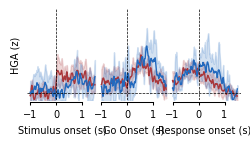

In [20]:
rois = ['AIC']
colors = [red, blue]

# subset = HGAs[
#     (HGAs.description == 'Repeat')
#     & (HGAs.modality=='sound')
#     & (HGAs.roi.isin(rois))
# ]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.subject=='D0094')
    & (HGAs.roi.isin(rois) | HGAs.label.str.contains('Opercular'))
]

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(7*cm, 3*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
line1 = sns.lineplot(
    data=subset[(subset.phase == 'stimulus')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax1,
    palette=colors,
    legend=False,
    lw=1
)

line3 = sns.lineplot(
    data=subset[(subset.phase == 'go')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax2,
    palette=colors,
    legend=False,
    lw=1
)

line4 = sns.lineplot(
    data=subset[(subset.phase == 'response')],
    x='time',
    y='value',
    hue='roi',
    hue_order=['AIC', 'IFG'],
    ax=ax3,
    palette=colors,
    legend=True,
    lw=1
)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == ax2 and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.2)
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Go Onset (s)', fontsize=7)   
ax3.set_xlabel('Response onset (s)', fontsize=7)   

ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)

# plt.savefig('../img/fig2/fig2_AIPI_temporal_LS.svg', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
subset = HGAs[
    (HGAs.description == 'Decision')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.roi.isin(rois) | HGAs.label.str.contains('Opercular'))
]

subset[subset.roi=='IFG'].subject.unique()

array(['D0094', 'D0032', 'D0035'], dtype=object)

In [8]:
subset[subset.roi=='AIC'].subject.unique()

array(['D0028', 'D0092', 'D0094', 'D0027', 'D0032', 'D0047', 'D0068',
       'D0079', 'D0080', 'D0096', 'D0103'], dtype=object)

# Anterior insula respond to picture naming

## Load zscore instead of just the significant HGA now

In [43]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        # 'SentenceRep',
        # 'PhonemeSequence'
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
ZAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    ZAs.append(df)

ZAs = pd.concat(ZAs)

# rename both phase : Resp and Response to Resp
ZAs.loc[ZAs.phase == 'Resp', 'phase'] = 'Response'
ZAs.loc[ZAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
ZAs['phase'] = ZAs['phase'].str.lower()

# rename INS to 'Insula'
ZAs.loc[ZAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
ZAs.loc[ZAs.roi == 'PrG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'PoG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'Subcentral', 'roi'] = 'SMC'


ZAs.loc[ZAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
ZAs.loc[ZAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
ZAs.loc[ZAs.roi=='CG', 'roi'] = 'ACC'
ZAs.head()

100%|██████████| 816/816 [01:08<00:00, 11.98it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [44]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
ZAs['roi'] = ZAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(ZAs[ZAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(ZAs[ZAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = ZAs[ZAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
ZAs.head()

AIC electrode count: 611840
PIC electrode count: 621440


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


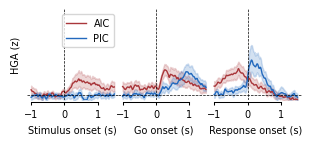

In [45]:
rois = ['AIC','PIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.task == 'PictureNaming')
    & (HGAs.roi.isin(rois))
    & (HGAs.hemi == 'L')
    & (HGAs.description == 'Repeat')
    & (HGAs.subject!='D0121')
    & (HGAs.modality=='image')
]

subset_z = ZAs[
    (ZAs.task == 'PictureNaming')
    & (ZAs.channel.isin(subset.channel.unique()))
    & (ZAs.hemi == 'L')
    & (ZAs.description == 'Repeat')
    & (ZAs.subject!='D0121')
    & (ZAs.modality=='image')
]


phases = ['stimulus', 'go', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[0] else False
    sns.lineplot(
        data=subset_z[(subset_z.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

# plt.savefig('../img/fig3/fig3_AIPI_temporal_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
rois = ['AIC','PIC']

spatial = subset_z[
    (subset_z.phase == 'stimulus')
    & (subset_z.time>0)
    & (subset_z.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0079_LPI8-9,0.096501,-34.099114,-9.593679,14.044702,AIC,ctx_lh_G_insular_short,stimulus,L,D0079,Repeat,PictureNaming
1,D0080_LAI4-5,0.208840,-33.557218,15.008318,-0.804909,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0080,Repeat,PictureNaming
2,D0080_LAI5-6,0.438476,-33.399199,16.642277,2.455954,AIC,ctx_lh_G_insular_short,stimulus,L,D0080,Repeat,PictureNaming
3,D0080_LAI6-7,0.795266,-32.992777,18.329265,5.976038,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0080,Repeat,PictureNaming
4,D0080_LAI7-8,0.140730,-32.582864,20.162594,8.934869,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0080,Repeat,PictureNaming


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 14:35:37.614 (2985.230s) [    7F7BAA9E9440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2eff1310): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 14:35:37.696 (2985.312s) [    7F7BAA9E9440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2eff1310): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

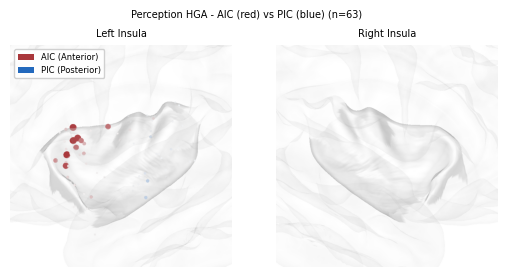

In [32]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)
plt.savefig('../img/fig3/fig3_AIPI_spatial_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Decision button press

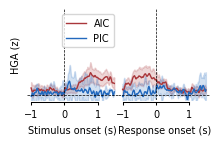

In [ ]:
rois = ['AIC','PIC']
colors = [red, blue]

subset = HGAs[
    (HGAs.task == 'LexicalNoDelay')
    & (HGAs.roi.isin(rois))
    & (HGAs.hemi == 'L')
    & (HGAs.description == 'Decision')
    & (HGAs.subject!='D0121')
]

subset_z = ZAs[
    (ZAs.task == 'LexicalNoDelay')
    & (ZAs.channel.isin(subset.channel.unique()))
    & (ZAs.hemi == 'L')
    & (ZAs.description == 'Decision')
    & (ZAs.subject!='D0121')
]

phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[0] else False
    sns.lineplot(
        data=subset_z[(subset_z.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.savefig('../img/fig3/fig3_AIPI_temporal_Buttonpress.svg', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
rois = ['AIC','PIC']

spatial = subset_z[
    (subset_z.phase == 'stimulus')
    & (subset_z.time>0)
    & (subset_z.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()


,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0028_LAI1-2,0.133314,-34.700069,8.872246,-13.792580,AIC,ctx_lh_G_insular_short,stimulus,L,D0028,Decision,LexicalNoDelay
1,D0028_LAI3-4,0.133492,-34.543239,15.001830,0.344973,AIC,ctx_lh_G_insular_short,stimulus,L,D0028,Decision,LexicalNoDelay
2,D0028_LPI2-3,-0.089091,-38.983494,-6.830616,-1.953703,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,stimulus,L,D0028,Decision,LexicalNoDelay
3,D0086_LPI2-3,0.044781,-35.794073,-3.309629,-5.081076,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,stimulus,L,D0086,Decision,LexicalNoDelay
4,D0092_LIA3-4,0.155771,-32.327604,20.570610,-0.181530,AIC,ctx_lh_G_insular_short,stimulus,L,D0092,Decision,LexicalNoDelay


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 13:24:25.708 (14450.747s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1304cd10): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 13:24:25.812 (14450.851s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1304cd10): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning

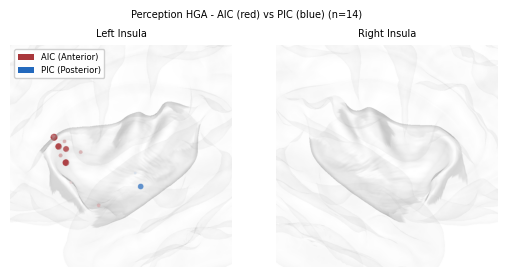

In [62]:

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)
# plt.savefig('../img/fig1/fig1_AIPI_spatial_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# Same input, different output

In [4]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
ZAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    ZAs.append(df)

ZAs = pd.concat(ZAs)

# rename both phase : Resp and Response to Resp
ZAs.loc[ZAs.phase == 'Resp', 'phase'] = 'Response'
ZAs.loc[ZAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
ZAs['phase'] = ZAs['phase'].str.lower()

# rename INS to 'Insula'
ZAs.loc[ZAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
ZAs.loc[ZAs.roi == 'PrG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'PoG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'Subcentral', 'roi'] = 'SMC'


ZAs.loc[ZAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
ZAs.loc[ZAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
ZAs.loc[ZAs.roi=='CG', 'roi'] = 'ACC'
ZAs.head()

100%|██████████| 428/428 [00:44<00:00,  9.53it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
ZAs['roi'] = ZAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(ZAs[ZAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(ZAs[ZAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = ZAs[ZAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
ZAs.head()

AIC electrode count: 240640
PIC electrode count: 257920


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [9]:
subset = ZAs[
    ZAs.task.isin(['LexicalDelay','LexicalNoDelay'])
]

subset['significance'] = subset.groupby(['channel'])['mask'].transform('any')

subset = subset[subset.significance == True]

common_channels = (subset[subset.task == 'LexicalDelay']['channel']
                  .unique())

common_channels = np.intersect1d(
    common_channels,
    subset[subset.task == 'LexicalNoDelay']['channel'].unique()
)

subset_common = subset[subset.channel.isin(common_channels)]

subset_common.head()

,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z,significance
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950,True
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615,True
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920,True
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506,True
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168,True


In [42]:
subset_common.subject.unique()

array(['D0024', 'D0026', 'D0027', 'D0028', 'D0029', 'D0053', 'D0054',
       'D0057', 'D0063', 'D0065', 'D0069', 'D0071', 'D0077', 'D0086',
       'D0090', 'D0092', 'D0094', 'D0100'], dtype=object)

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_4043662/4244979978.py:23: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_4043662/4244979978.py:23: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.lineplot(


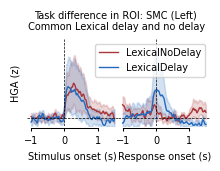

In [58]:
rois = ['SMC']
tasks = subset_common.task.unique()
descs = subset_common.description.unique()

colors = [red, blue, green]

subset_ = subset_common[
    (subset_common.roi.isin(rois))
    & (subset_common.hemi == 'L')
    & (subset_common.description == 'Decision')
]


phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset_[(subset_.phase == phase)],
        x='time',
        y='value',
        hue='task',
        hue_order=tasks,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)

plt.subplots_adjust(top=0.85)

plt.suptitle(f'Task difference in ROI: {rois[0]} (Left)'
             '\n Common Lexical delay and no delay', 
             fontsize=7, y=1.1)

plt.savefig(f'../img/misc/lexical_task_diff_{rois[0]}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
spatial = subset_[
    (subset_.phase == 'response')
    & (subset_.time>-1)
    & (subset_.time<1)
    ].groupby('channel').agg({
    'value': 'max',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0028_LPI1-2,0.227780,-38.438868,-7.224848,-9.879821,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,response,L,D0028,Decision,LexicalNoDelay
1,D0028_LPI2-3,0.337204,-38.983494,-6.830616,-1.953703,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,response,L,D0028,Decision,LexicalNoDelay
2,D0028_LPI3-4,0.174055,-39.538794,-6.389611,5.948131,PIC,ctx_lh_S_circular_insula_sup,response,L,D0028,Decision,LexicalNoDelay
3,D0086_LPI1-2,0.195839,-36.205655,-3.006571,-11.169696,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,response,L,D0086,Decision,LexicalNoDelay
4,D0086_LPI2-3,0.274012,-35.794073,-3.309629,-5.081076,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,response,L,D0086,Decision,LexicalNoDelay


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-18 13:08:10.616 (13303.323s) [    7FF54A588440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x260a96b0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-18 13:08:10.727 (13303.434s) [    7FF54A588440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x260a96b0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning

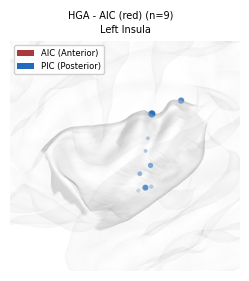

In [57]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 1, figsize=(8*cm, 8*cm))

axes.imshow(lh_brain.screenshot(mode="rgb"))
axes.axis("off")
axes.set_title("Left Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes.legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("HGA - AIC (red) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

plt.savefig(f'../img/misc/condition_difference_spatial_{rois[0]}.svg', dpi=300, bbox_inches='tight')

# Spatial distribution of HGA

## During Listening

In [13]:
rois = ['AIC','PIC']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.roi.isin(rois))
]

spatial = subset[
    (subset.phase == 'stimulus')
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0007_RFG1-2,0.408439,57.291674,20.558277,-14.696772,AIC,ctx_rh_G_insular_short,stimulus,R,D0007,Repeat,SentenceRep
1,D0022_LPIF3-4,0.536787,-34.587586,-19.677040,-2.311079,PIC,ctx_lh_S_circular_insula_inf,stimulus,L,D0022,Repeat,SentenceRep
2,D0022_LPIF4-5,0.654592,-40.742572,-20.437126,-4.055261,PIC,ctx_lh_S_circular_insula_inf,stimulus,L,D0022,Repeat,SentenceRep
3,D0023_R2IF1-2,0.135173,33.089530,-8.192050,18.614382,PIC,ctx_rh_S_circular_insula_sup,stimulus,R,D0023,Repeat,LexicalDelay
4,D0027_LAI2-3,0.165758,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0027,Repeat,LexicalDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 09:53:11.358 (1776.397s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1dcdfb70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 09:53:11.427 (1776.467s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1dcdfb70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

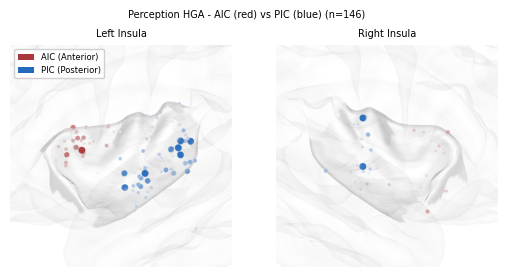

In [14]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

plt.savefig('../img/fig2/fig2_AIPI_spatial_Listen.svg', dpi=300, bbox_inches='tight')

## During Go

In [18]:
rois = ['AIC','PIC']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.roi.isin(rois))
]

spatial = subset[
    (subset.phase == 'go')
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0022_LPIF3-4,0.554398,-34.587586,-19.677040,-2.311079,PIC,ctx_lh_S_circular_insula_inf,go,L,D0022,Repeat,SentenceRep
1,D0022_LPIF4-5,0.334432,-40.742572,-20.437126,-4.055261,PIC,ctx_lh_S_circular_insula_inf,go,L,D0022,Repeat,PhonemeSequence
2,D0023_R2IF1-2,0.216992,33.089530,-8.192050,18.614382,PIC,ctx_rh_S_circular_insula_sup,go,R,D0023,Repeat,LexicalDelay
3,D0027_LAI2-3,0.283852,-32.470676,9.175895,4.597974,AIC,ctx_lh_S_circular_insula_sup,go,L,D0027,Repeat,LexicalDelay
4,D0027_LAI3-4,0.400751,-30.700923,13.124481,11.623351,AIC,ctx_lh_S_circular_insula_sup,go,L,D0027,Repeat,LexicalDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 09:55:00.318 (1885.357s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x79b2340): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 09:55:00.405 (1885.444s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x79b2340): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: eg

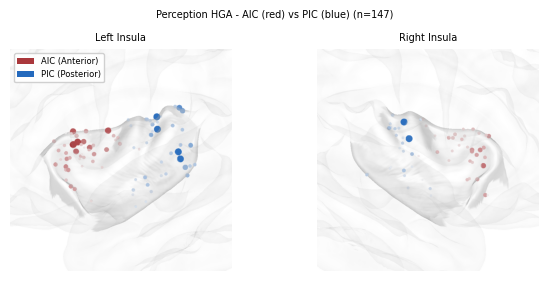

In [ ]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

plt.savefig('../img/fig2/fig2_AIPI_spatial_Go.svg', dpi=300, bbox_inches='tight')
plt.show()

## During Response

In [21]:
rois = ['AIC','PIC']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.roi.isin(rois))
]

spatial = subset[
    (subset.phase == 'response')
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0007_RFG1-2,0.310247,57.291674,20.558277,-14.696772,AIC,ctx_rh_G_insular_short,response,R,D0007,Repeat,SentenceRep
1,D0022_LPIF3-4,1.037866,-34.587586,-19.677040,-2.311079,PIC,ctx_lh_S_circular_insula_inf,response,L,D0022,Repeat,SentenceRep
2,D0022_LPIF4-5,1.179111,-40.742572,-20.437126,-4.055261,PIC,ctx_lh_S_circular_insula_inf,response,L,D0022,Repeat,SentenceRep
3,D0023_R2IF1-2,0.270674,33.089530,-8.192050,18.614382,PIC,ctx_rh_S_circular_insula_sup,response,R,D0023,Repeat,LexicalDelay
4,D0023_R2IF2-3,0.153073,36.686262,-8.172090,19.151989,PIC,ctx_rh_S_circular_insula_sup,response,R,D0023,Repeat,LexicalDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 09:56:56.588 (2001.627s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x8ebf890): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-30 09:56:56.687 (2001.727s) [    7F4F82D19440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x8ebf890): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: eg

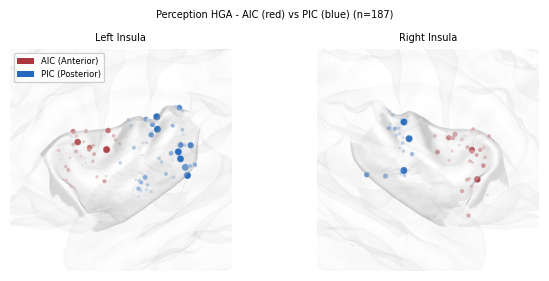

In [22]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

plt.savefig('../img/fig2/fig2_AIPI_spatial_Response.svg', dpi=300, bbox_inches='tight')
plt.show()

## During Button Press

In [13]:
rois = ['AIC','PIC']

subset = HGAs[
    (HGAs.task=='LexicalNoDelay')
    & (HGAs.description == 'Decision')
    & (HGAs.roi.isin(rois))
]

spatial = subset[
    (subset.phase == 'response')
    # & (subset.time>0)
    # & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()


,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0028_LAI1-2,0.133045,-34.700069,8.872246,-13.792580,AIC,ctx_lh_G_insular_short,response,L,D0028,Decision,LexicalNoDelay
1,D0028_LAI3-4,0.147900,-34.543239,15.001830,0.344973,AIC,ctx_lh_G_insular_short,response,L,D0028,Decision,LexicalNoDelay
2,D0028_LPI2-3,0.009403,-38.983494,-6.830616,-1.953703,PIC,ctx_lh_G_Ins_lg_and_S_cent_ins,response,L,D0028,Decision,LexicalNoDelay
3,D0053_RPI1-2,0.159536,35.758579,3.498101,-8.729308,PIC,ctx_rh_G_Ins_lg_and_S_cent_ins,response,R,D0053,Decision,LexicalNoDelay
4,D0057_RAI5-6,0.274934,31.937746,11.592552,7.984656,AIC,ctx_rh_S_circular_insula_sup,response,R,D0057,Decision,LexicalNoDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 14:02:15.501 ( 983.116s) [    7F7BAA9E9440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2b93a5d0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 14:02:15.580 ( 983.196s) [    7F7BAA9E9440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2b93a5d0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

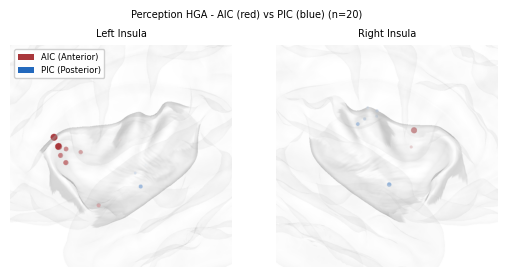

In [14]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

plt.savefig('../img/fig3/fig3_AIPI_spatial_Decision.svg', dpi=300, bbox_inches='tight')
plt.show()

## During picture naming

In [11]:
rois = ['AIC','PIC']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='image')
    & (HGAs.roi.isin(rois))
]

spatial = subset[
    (subset.phase == 'stimulus')
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()


,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0076_RPI1-2,0.038773,41.622795,-6.750406,-4.953020,PIC,ctx_rh_G_Ins_lg_and_S_cent_ins,stimulus,R,D0076,Repeat,PictureNaming
1,D0076_RPI2-3,0.082228,41.107107,-7.009331,-0.789067,PIC,ctx_rh_G_Ins_lg_and_S_cent_ins,stimulus,R,D0076,Repeat,PictureNaming
2,D0076_RPI3-4,0.193708,40.591419,-7.268257,3.374885,PIC,ctx_rh_G_Ins_lg_and_S_cent_ins,stimulus,R,D0076,Repeat,PictureNaming
3,D0080_LAI5-6,0.438476,-33.399199,16.642277,2.455954,AIC,ctx_lh_G_insular_short,stimulus,L,D0080,Repeat,PictureNaming
4,D0080_LAI6-7,0.795266,-32.992777,18.329265,5.976038,AIC,ctx_lh_S_circular_insula_sup,stimulus,L,D0080,Repeat,PictureNaming


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 14:01:24.914 ( 932.530s) [    7F7BAA9E9440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2c135a70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 14:01:24.997 ( 932.612s) [    7F7BAA9E9440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2c135a70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

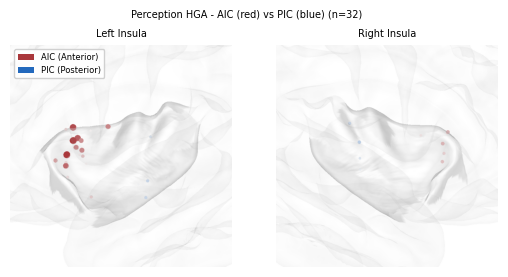

In [12]:
# ============================================================
# 3D Insula HGA Visualization - AIC (red) vs PIC (blue)
# 保持与 Cell 13 完全相同的参数，只改变颜色
# ============================================================

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 25

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 添加图例说明颜色
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)
plt.savefig('../img/fig1/fig1_AIPI_spatial_PictureNaming.svg', dpi=300, bbox_inches='tight')
plt.show()

# SIS of posterior insula

roi  condition
HG   Listen        26
     Speak         26
PIC  Listen        88
     Speak         92
STG  Listen       120
     Speak        109
Name: channel, dtype: int64


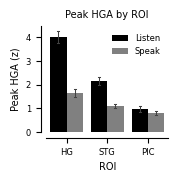

In [39]:
# 筛选目标脑区和条件 - 调整顺序
from matplotlib.ticker import MultipleLocator


rois_compare = ['HG', 'STG', 'PIC']  # HG -> STG -> PIC
phases_compare = ['stimulus', 'response']  # stimulus=听, response=说

# 筛选数据
df_compare = HGAs[
    (HGAs['roi'].isin(rois_compare)) &
    (HGAs['phase'].isin(phases_compare)) &
    (HGAs['description'] == 'Repeat') &
    (HGAs['modality'] == 'sound') &
    (HGAs['time'] > 0) & (HGAs['time'] < 1) 
].copy()

# 计算每个电极的 peak 和 mean HGA
electrode_stats = df_compare.groupby(['channel', 'roi', 'phase']).agg(
    peak_hga=('value', 'max'),
    mean_hga=('value', 'mean')
).reset_index()

# 重命名 phase 为更直观的名称
electrode_stats['condition'] = electrode_stats['phase'].map({
    'stimulus': 'Listen',
    'response': 'Speak'
})

fig, ax = plt.subplots(1, 1, figsize=(4*cm, 3.5*cm))

sns.barplot(data=electrode_stats, 
            x='roi',
            y='peak_hga', 
            hue='condition',
            palette={'Listen': 'black', 'Speak': 'gray'},
            order=rois_compare, 
            ax=ax, 
            errorbar='se', 
            capsize=0.1,
            errwidth=0.75)


ax.set_xlabel('ROI', fontsize=fontsize)
ax.set_ylabel('Peak HGA (z)', fontsize=fontsize)
ax.set_title('Peak HGA by ROI', fontsize=fontsize)
ax.legend(title='', fontsize=fontsize-1, frameon=False)
ax.yaxis.set_major_locator(MultipleLocator(1))

for ax in fig.axes:
    ax.tick_params(labelsize=fontsize-1)
    sns.despine(ax=ax, offset=4)


print(electrode_stats.groupby(['roi', 'condition'])['channel'].nunique())
plt.savefig('../img/fig2/fig2_peak_hga_by_roi.svg', dpi=300)

In [29]:
# Build scatter_df: align each electrode's Perception vs Production
metric = 'peak_hga'  # or 'peak_hga'

scatter_df = (
    electrode_stats
    .pivot_table(index=['channel', 'roi'], columns='condition', values=metric, aggfunc='first')
    .dropna(subset=['Listen', 'Speak'])
    .reset_index()
)

# add coords/metadata back (one row per channel)
coords = (HGAs.groupby('channel')[['x','y','z','hemi','subject','label']].first().reset_index())
scatter_df = scatter_df.merge(coords, on='channel', how='left')

scatter_df.head()

,channel,roi,Listen,Speak,x,y,z,hemi,subject,label
0,D0005_LTG14-15,STG,3.506131,1.376253,-68.886726,-28.295294,0.243498,L,D0005,ctx_lh_G_temp_sup-Lateral
1,D0005_LTG15-16,STG,3.157964,1.245044,-69.639740,-38.151283,4.609248,L,D0005,ctx_lh_G_temp_sup-Lateral
2,D0005_LTG4-5,STG,2.213470,0.749295,-63.895071,-1.988314,1.863490,L,D0005,ctx_lh_G_temp_sup-Lateral
3,D0007_RFG1-2,AIC,1.434964,0.724627,57.291674,20.558277,-14.696772,R,D0007,ctx_rh_G_insular_short
4,D0022_LMIF5-6,HG,2.216819,1.285263,-49.716957,-12.270617,-12.142812,L,D0022,ctx_lh_S_temporal_transverse


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-02 22:20:27.177 (1477.537s) [    7FFAF1541440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x11ad6a00): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-02 22:20:27.238 (1477.598s) [    7FFAF1541440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x29d73530): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

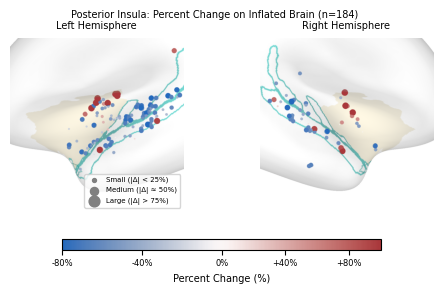

In [35]:
# ============================================================
# 方案二: 在 Inflated Brain 上画 Percent Change (仅 PIC)
# 使用 vlag colormap 展示 Posterior Insula 的抑制梯度
# ============================================================

from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors
import pyvista as pv

# 使用上面计算好的 scatter_df，只筛选 Posterior Insula
rois_brain = ['PIC', 'HG', 'STG']  # 只显示 Posterior Insula
brain_df = scatter_df[scatter_df['roi'].isin(rois_brain)].copy()

# 计算百分比变化（相对于 Perception）
brain_df['Percent_Change'] = (brain_df['Speak'] - brain_df['Listen']) / brain_df['Listen'] * 100

# 读取labels用于过滤电极
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# 构建每个ROI对应的label顶点集合
def get_roi_vertices(labels, roi_name, hemi):
    vertices = set()
    for lab in labels:
        name = lab.name
        if lab.hemi != hemi:
            continue
        if roi_name == 'PIC' and 'ins' in name.lower():
            vertices.update(lab.vertices)
    return vertices

# 创建Brain对象 - 使用 inflated 表面
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.95, 0.95, 0.95), alpha=0.3, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.95, 0.95, 0.95), alpha=0.3, size=(800, 800)
)

# 加载表面数据
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
lh_infl_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.inflated")
lh_tree = cKDTree(lh_pial_coords)

rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
rh_infl_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.inflated")
rh_tree = cKDTree(rh_pial_coords)

# 使用 seaborn 的 vlag colormap
cmap = sns.color_palette("vlag", as_cmap=True)  # vlag: 蓝-白-红

# 根据实际数据范围设置 colormap 和大小映射
pc_values = brain_df['Percent_Change'].values
vmin, vmax = -80, 100  # 百分比范围
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# 点大小映射参数 - 基于百分比变化的绝对值
size_min, size_max = 4, 30

def percent_change_to_size(pc, size_min, size_max):
    """根据百分比变化的绝对值映射点大小"""
    abs_pc = np.abs(pc)
    # 将绝对百分比映射到大小范围
    normalized = np.clip(abs_pc / 100, 0, 1)  # 归一化到 0-1
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_percent_change_size(brain, coords, pc_vals, tree, pial_coords, infl_coords, cmap, norm, size_min, size_max):
    _, indices = tree.query(coords)
    coords_on_infl = infl_coords[indices]
    
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        pc = pc_vals[i]
        
        # 颜色基于百分比变化（使用 vlag colormap）
        color = cmap(norm(pc))[:3]
        
        # 大小基于百分比变化的绝对值
        size = percent_change_to_size(pc, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            opacity=1,
        )

# 准备数据
cord = brain_df[['x', 'y', 'z']].values
pc_values = brain_df['Percent_Change'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_pc = pc_values[mask_lh]
    add_electrodes_with_percent_change_size(lh_brain, lh_cord, lh_pc, lh_tree, lh_pial_coords, lh_infl_coords, 
                                           cmap, norm, size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_pc = pc_values[mask_rh]
    add_electrodes_with_percent_change_size(rh_brain, rh_cord, rh_pc, rh_tree, rh_pial_coords, rh_infl_coords, 
                                           cmap, norm, size_min, size_max)

# 添加 ROI 边界
# Posterior Insula 边界

insula_patterns = [
    'G_insular_short',
    'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant',
    'S_circular_insula_inf',
    'S_circular_insula_sup',
]

for lab in labels:
    name = lab.name
    if any(p in name for p in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# STG 边界
for lab in labels:
    name = lab.name
    if 'G_temp_sup' in name:
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=True, color=stg_color, alpha=0.8)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=True, color=stg_color, alpha=0.8)

# 计算听觉相关脑区的中心点，用于调整视角
def get_roi_center(labels, roi_patterns, hemi):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in roi_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        if hemi == 'lh':
            coords = lh_infl_coords[vertices]
        else:
            coords = rh_infl_coords[vertices]
        return coords.mean(axis=0)
    return None

# 听觉相关脑区模式
auditory_patterns = ['G_temp_sup', 'G_temp_sup-G_T_transv'] + insula_patterns
lh_auditory_center = get_roi_center(labels, auditory_patterns, 'lh')
rh_auditory_center = get_roi_center(labels, auditory_patterns, 'rh')

# 设置视角 - 聚焦在听觉区域
for brain, center in [(lh_brain, lh_auditory_center), (rh_brain, rh_auditory_center)]:
    if center is not None:
        brain.show_view(azimuth=180 if brain == lh_brain else 0, 
                       elevation=90, 
                       distance=230,  # 缩短距离，更聚焦
                       focalpoint=center)
    else:
        brain.show_view(view="lateral", distance=150)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(15*cm, 7*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Hemisphere", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Hemisphere", fontsize=fontsize)

# 添加 colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, aspect=30)
cbar.set_label('Percent Change (%)', fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize-1)
cbar.set_ticks([-80, -40, 0, 40, 80])
cbar.ax.set_xticklabels(['-80%', '-40%', '0%', '+40%', '+80%'])

# 添加大小图例
from matplotlib.patches import Patch
size_legend_elements = [
    plt.scatter([], [], s=size_min*2, c='gray', label=f'Small (|Δ| < 25%)'),
    plt.scatter([], [], s=(size_min + (size_max-size_min)*0.5)*2, c='gray', label=f'Medium (|Δ| ≈ 50%)'),
    plt.scatter([], [], s=size_max*2, c='gray', label=f'Large (|Δ| > 75%)')
]
axes[0].legend(handles=size_legend_elements, loc='lower right', fontsize=fontsize-2, framealpha=0.8)

plt.suptitle("Posterior Insula: Percent Change on Inflated Brain (n={})".format(len(brain_df)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.25)
plt.savefig('../img/fig2/fig2_SIS.svg', dpi=300, bbox_inches='tight')

# Check the Mime condition

In [63]:
HGAs[(HGAs.task == 'SentenceRep')].description.unique()

array(['Mime', 'Passive', 'Repeat'], dtype=object)

In [70]:
subset = HGAs[
    (HGAs.task == 'SentenceRep')
    & (HGAs.phase == 'go')
    & (HGAs.description=='Repeat')
    & (HGAs.time>0)
    & (HGAs.time<0.5)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

subset.head()

,channel,value,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0005_LTG29-30,0.166033,-54.534528,-29.265764,-28.078430,ITG,ctx_lh_G_temporal_inf,go,L,D0005,Repeat,SentenceRep
1,D0005_LTG30-31,0.221984,-55.770381,-38.615740,-23.875112,ITG,ctx_lh_G_temporal_inf,go,L,D0005,Repeat,SentenceRep
2,D0005_MST1-2,0.344462,-48.256259,-30.500590,-27.727256,ITG,ctx_lh_G_temporal_inf,go,L,D0005,Repeat,SentenceRep
3,D0005_PST2-3,1.094072,-28.376318,-70.705914,-17.258388,Intersection,Intersection,go,L,D0005,Repeat,SentenceRep
4,D0005_PST3-4,1.358680,-14.036695,-76.118701,-13.701689,Intersection,Intersection,go,L,D0005,Repeat,SentenceRep


In [73]:
subset = subset[
    ~subset.roi.isin(['Intersection(unknown)','Intersection',
                      'Amyg','Hipp','mOccG','OPC','LinG','OFCs',
                      'iOccGs','Thal','LatV','InfLatV','OccS','FuGs',
                      'Calcarine','PhG','FuG'])
]

# subset = subset[subset.roi.isin(['STG'])]

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-21 20:33:31.333 (4304.508s) [    7FB3B662D440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x183b17d0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-21 20:33:31.462 (4304.637s) [    7FB3B662D440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1ca1b790): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

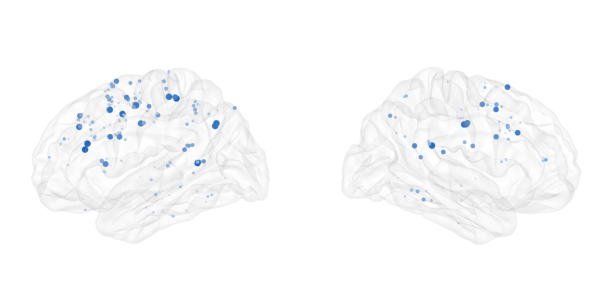

In [74]:
# Pial version - listen_hga
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 创建Brain对象 - pial surface
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# 从 listen_hga 获取数据
cord = subset[['x', 'y', 'z']].values
hga_values = subset['value'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化
cmap = blues
vmin, vmax = 0, np.percentile(hga_values, 96)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数
size_min, size_max = 5, 32

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

# 加载 pial 表面数据
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

def add_electrodes_with_size(brain, coords, hga_vals, cmap, norm, size_min, size_max):
    for i in range(len(coords)):
        pt = coords[i:i+1]
        hga = hga_vals[i]
        color = cmap(norm(hga))[:3]
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )

# 处理左半球电极 - 投影到 pial 表面
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_pial = lh_coords_pial[lh_indices]
    
    add_electrodes_with_size(lh_brain, lh_cord_on_pial, lh_hga, cmap, norm, size_min, size_max)

# 处理右半球电极 - 投影到 pial 表面
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_pial = rh_coords_pial[rh_indices]
    
    add_electrodes_with_size(rh_brain, rh_cord_on_pial, rh_hga, cmap, norm, size_min, size_max)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

# plt.savefig('../figs/papers/fig1/fig1_HGA_perceptiononly_perception.svg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-21 20:03:17.293 (2490.469s) [    7FB3B662D440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x37b35cd0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-21 20:03:17.390 (2490.565s) [    7FB3B662D440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2a18c9a0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

左半球: 8 电极
右半球: 6 电极


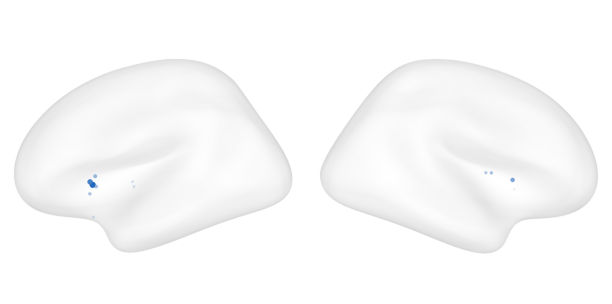

In [44]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 创建Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

# 从 listen_hga 获取数据
cord = subset[['x', 'y', 'z']].values
hga_values = subset['value'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化
cmap = blues
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数
size_min, size_max = 10, 30

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

# 加载表面数据
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_infl_path = f"{recon_dir}/fsaverage/surf/rh.inflated"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_coords_infl, _ = mne.read_surface(rh_infl_path)
rh_tree = cKDTree(rh_coords_pial)

def add_electrodes_with_size(brain, coords, hga_vals, cmap, norm, size_min, size_max):
    for i in range(len(coords)):
        pt = coords[i:i+1]
        hga = hga_vals[i]
        color = cmap(norm(hga))[:3]
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )

# 处理左半球电极 - 不筛选，画所有电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_infl = lh_coords_infl[lh_indices]
    
    print(f"左半球: {len(lh_cord)} 电极")
    add_electrodes_with_size(lh_brain, lh_cord_on_infl, lh_hga, cmap, norm, size_min, size_max)

# 处理右半球电极 - 不筛选，画所有电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_infl = rh_coords_infl[rh_indices]
    
    print(f"右半球: {len(rh_cord)} 电极")
    add_electrodes_with_size(rh_brain, rh_cord_on_infl, rh_hga, cmap, norm, size_min, size_max)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

# plt.savefig('../img/fig1/fig1_peak_listening.svg', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# About Timing

In [ ]:
import pandas as pd

def get_onset_latency(df):
    """
    Get ONSET latency (first significant time point) in the significant regions.
    Assumes 'mask' column indicates significant clusters.
    """
    results = []
    
    # 按 channel 和 phase 分组
    for (channel, phase, description, task), group in df.groupby(['channel', 'phase', 'description','task']):
        # 1. 只筛选显著的时间点
        sig_data = group[group['mask'] == True]
        
        if len(sig_data) == 0:
            continue
            
        # -------------------------------------------------------
        # 修改核心逻辑：不再找 idxmax (Peak)，而是找最早的时间点 (Onset)
        # -------------------------------------------------------
        
        # 2. 必须按时间排序，确保取到的是起始点
        # 假设你的时间列叫 'time'
        sig_data = sig_data.sort_values('time')
        
        # # 3. 取第一行，这就是 Onset
        onset_row = sig_data.iloc[0]
        
        # peak_idx = sig_data['value'].idxmax()
        # onset_row = sig_data.loc[peak_idx]
        
        
        # 4. (可选) 鲁棒性检查：
        # 有时候 mask 可能是断断续续的（比如 [True, False, True, True...]）
        # 如果你想忽略那种非常短暂的偶然显著（比如只持续了10ms），
        # 你可以在这里加逻辑判断 consecutive points。
        # 但通常如果前面的置换检验做好了 cluster correction，直接取第一个点即可。

        results.append({
            'channel': channel,
            'description': description,
            'task': task,
            'phase': phase,
            'onset_latency': onset_row['time'],      # 这里改名为 onset_latency
            'peak_value': onset_row['value'],        # 记录一下 onset 时的强度，或者你可以保留 max value
            'subject': onset_row['subject'],
            'roi': onset_row['roi'],
            'hemi': onset_row['hemi'],
            'label': onset_row['label'],
            'x': onset_row['x'],
            'y': onset_row['y'],
            'z': onset_row['z'],
        })
    
    return pd.DataFrame(results)

latency = get_onset_latency(HGAs[(HGAs.description=='Repeat') & (HGAs.modality=='sound')])
latency.head()

,channel,description,task,phase,onset_latency,peak_value,subject,roi,hemi,label,x,y,z
0,D0005_LTG13-14,Repeat,SentenceRep,stimulus,0.335938,0.449499,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-67.238742,-17.127162,-3.621204
1,D0005_LTG14-15,Repeat,SentenceRep,response,0.242188,0.291811,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-68.886726,-28.295294,0.243498
2,D0005_LTG14-15,Repeat,SentenceRep,stimulus,0.242188,0.329092,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-68.886726,-28.295294,0.243498
3,D0005_LTG15-16,Repeat,SentenceRep,response,0.250000,0.266283,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-69.639740,-38.151283,4.609248
4,D0005_LTG15-16,Repeat,SentenceRep,stimulus,0.250000,0.242492,D0005,STG,L,ctx_lh_G_temp_sup-Lateral,-69.639740,-38.151283,4.609248


In [66]:
# remove entry if stimulus onset_latency is <0
exclude = latency[(latency.phase == 'stimulus') & (latency['onset_latency'] < 0)].index
latency = latency.drop(exclude)

In [73]:
import statsmodels.formula.api as smf

target_rois = ['STG',
               'SMC', 
               'IFG',
               'AIC',
               'PIC',
               ] 


df_model = latency[(latency['roi'].isin(target_rois)) & (latency.phase=='stimulus')].copy()

df_model['onset_latency'] = pd.to_numeric(df_model['onset_latency'], errors='coerce')

model = smf.mixedlm("onset_latency ~ roi*hemi", data=df_model, groups=df_model["subject"])

result = model.fit(method=['nm', 'lbfgs'], maxiter=5000)

print(result.summary())

             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  onset_latency
No. Observations:   406      Method:              REML         
No. Groups:         65       Scale:               0.0229       
Min. group size:    1        Log-Likelihood:      131.1344     
Max. group size:    32       Converged:           Yes          
Mean group size:    6.2                                        
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.381    0.033 11.390 0.000  0.316  0.447
roi[T.IFG]           -0.053    0.045 -1.171 0.241 -0.140  0.035
roi[T.PIC]           -0.214    0.037 -5.794 0.000 -0.287 -0.142
roi[T.SMC]           -0.217    0.036 -5.999 0.000 -0.288 -0.146
roi[T.STG]           -0.237    0.036 -6.539 0.000 -0.308 -0.166
hemi[T.R]            -0.083    0.059 -1.405 0.160 -0.

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_550296/1889092901.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(data=df_model,
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_550296/1889092901.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=df_model,


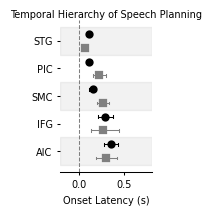

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

roi_order = [
            'STG', 
            'PIC',
            'SMC', 
            'IFG',
            'AIC', 
    ]

# 2. 设置画布风格
fig, ax = plt.subplots(figsize=(3*cm, 5*cm))

# 3. 画核心的点和误差棒 (Pointplot)
# join=False: 不要把点连成线，我们要的是独立的估计值
# dodge=0.5: 让左右脑的点错开，不要重叠
# errwidth & capsize: 调整误差棒的粗细和帽子，模仿参考图风格
ax = sns.pointplot(data=df_model, 
                   x="onset_latency", 
                   y="roi", 
                   hue="hemi",
                   order=roi_order,
                   palette={"L": 'black', "R": 'gray'}, # 相同颜色
                   join=False,      # 关键：不连线
                   legend=False,
                   dodge=0.5,       # 关键：左右错开
                   markers=["o", "s"], # 左脑圆点，右脑方块，增加区分度
                   scale=0.8,       # 点的大小
                   errorbar=('ci', 95), # 显示 95% 置信区间 (或者用 'se' 显示标准误)
                   capsize=0.1,     # 误差棒的小帽子
                   errwidth=0.75)

# 4. 添加 0ms 参考线 (发声时刻)
# zorder=0 确保线在数据点后面
plt.axvline(0, color='black', linestyle='--', linewidth=0.75, alpha=0.5, zorder=0)

# 5. 添加背景条纹 (可选，像参考图那样的灰白相间)
# 这一步是为了模仿参考图的灰色背景带，增加可读性
for i in range(len(roi_order)):
    if i % 2 == 0: # 偶数行加灰色背景
        plt.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax.set_xlim(-0.2, .8)
# 6. 美化调整
plt.xlabel("Onset Latency (s)", fontsize=7)
plt.ylabel("") # ROI 名字已经在 Y 轴刻度上了，不需要 Label
plt.title("Temporal Hierarchy of Speech Planning", fontsize=7, pad=2 )

# 调整图例

# 去掉上方和右侧边框
sns.despine(left=True)

# 调整 Y 轴刻度文字样式

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)
    
fig.savefig("../img/fig2/fig2_insula_temporal_stimulus.svg", dpi=300, bbox_inches='tight')

In [75]:
import statsmodels.formula.api as smf

target_rois = ['STG',
               'SMC', 
               'IFG',
               'AIC',
               'PIC',
               ] 


df_model = latency[(latency['roi'].isin(target_rois)) & (latency.phase=='response')].copy()

df_model['onset_latency'] = pd.to_numeric(df_model['onset_latency'], errors='coerce')

model = smf.mixedlm("onset_latency ~ roi*hemi", data=df_model, groups=df_model["subject"])

result = model.fit(method=['nm', 'lbfgs'], maxiter=5000)

print(result.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  onset_latency
No. Observations:    773      Method:              REML         
No. Groups:          69       Scale:               0.1501       
Min. group size:     1        Log-Likelihood:      -395.1839    
Max. group size:     61       Converged:           Yes          
Mean group size:     11.2                                       
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept            -0.515    0.048 -10.828 0.000 -0.609 -0.422
roi[T.IFG]            0.024    0.086   0.279 0.780 -0.144  0.192
roi[T.PIC]            0.407    0.063   6.467 0.000  0.284  0.530
roi[T.SMC]           -0.061    0.055  -1.106 0.269 -0.169  0.047
roi[T.STG]            0.351    0.061   5.717 0.000  0.230  0.471
hemi[T.R]             0.161    0.072   

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_550296/3973327262.py:23: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(data=df_model_copy,
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_550296/3973327262.py:23: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=df_model_copy,


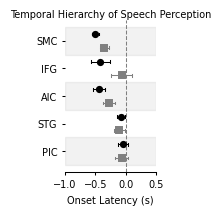

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 设定 ROI 顺序 (建议按照时间先后或者从前到后的解剖位置排序)
roi_order = [
    'SMC',                  # -0.367 (Anticipation/Prediction)
    'IFG',                  #  Baseline (Top-down Processing)
    'AIC',                  # 0.061 (Latest)
    'STG',                  # -0.098 (Auditory Processing)
    'PIC',
]

# 2. 设置画布风格
fig, ax = plt.subplots(figsize=(3*cm, 5*cm))

# 3. 画核心的点和误差棒 (Pointplot)
# join=False: 不要把点连成线，我们要的是独立的估计值
# dodge=0.5: 让左右脑的点错开，不要重叠
# errwidth & capsize: 调整误差棒的粗细和帽子，模仿参考图风格
df_model_copy = df_model.copy()
df_model_copy.onset_latency = df_model_copy.onset_latency + 0.08

ax = sns.pointplot(data=df_model_copy, 
                   x="onset_latency", 
                   y="roi", 
                   hue="hemi",
                   order=roi_order,
                   palette={"L": 'black', "R": 'gray'}, # 相同颜色
                   join=False,      # 关键：不连线
                   legend=False,
                   dodge=0.5,       # 关键：左右错开
                   markers=["o", "s"], # 左脑圆点，右脑方块，增加区分度
                   scale=0.7,       # 点的大小
                   errorbar=('ci', 95), # 显示 95% 置信区间 (或者用 'se' 显示标准误)
                   capsize=0.1,     # 误差棒的小帽子
                   errwidth=0.75)

# 4. 添加 0ms 参考线 (发声时刻)
# zorder=0 确保线在数据点后面
plt.axvline(0, color='black', linestyle='--', linewidth=0.75, alpha=0.5, zorder=0)

# 5. 添加背景条纹 (可选，像参考图那样的灰白相间)
# 这一步是为了模仿参考图的灰色背景带，增加可读性
for i in range(len(roi_order)):
    if i % 2 == 0: # 偶数行加灰色背景
        plt.axhspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

# 6. 美化调整
plt.xlabel("Onset Latency (s)", fontsize=7)
plt.ylabel("") # ROI 名字已经在 Y 轴刻度上了，不需要 Label
plt.title("Temporal Hierarchy of Speech Perception", fontsize=7, pad=2 )

# 调整图例
ax.set_xlim(-1, 0.5)
# 去掉上方和右侧边框
sns.despine(left=True)

# 调整 Y 轴刻度文字样式
for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)
    
fig.savefig("../img/fig2/fig2_insula_temporal_response.svg", dpi=300, bbox_inches='tight')